<a href="https://colab.research.google.com/github/nihedzaoui/flyrank-ml-internship/blob/main/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nihedzaoui/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

I use a **Random Forest classifier** for this modeling lane.

The goal is to improve the Week-4 rule-based ranking of content that may need attention. Random Forest is a good fit because it can capture non-linear relationships and interactions between the available signals without requiring a linear relationship between features and the target.

The model will predict the probability that an item belongs to the `is_declining_label` class. I will use this probability as the ranking score and evaluate the resulting top-50 items using **Precision@50**, matching the ranking-oriented evaluation used for the baseline.

I will not use `trend_direction`, `trend_pct`, or `is_declining_label` as input features because the target is derived from the trend information. I will also exclude identifier columns and other label-derived/product-rule fields that could introduce leakage.

The purpose is not to reward model complexity. The Random Forest will only be considered useful if it improves the measured Precision@50 over the Week-4 baseline on the same data and an honest split.

In [ ]:
!git clone https://github.com/nihedzaoui/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 184 (delta 76), reused 93 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (184/184), 1.89 MiB | 13.62 MiB/s, done.
Resolving deltas: 100% (76/76), done.


In [ ]:
!find /content/flyrank-ml-internship -type f | grep -E "content_refresh|\.csv$"

/content/flyrank-ml-internship/outputs/refresh_queue_sample.csv
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the same dataset used in Week 4
DATA_PATH = Path(
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# Create the target from the existing trend direction.
# "down" = declining content.
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nTarget proportions:")
print(df["is_declining_label"].value_counts(normalize=True))

print("\nRequired columns:")
display(
    df[
        [
            "content_id",
            "client_id",
            "days_since_last_update",
            "impressions_90d",
            "trend_direction",
            "is_declining_label",
        ]
    ].head()
)

Dataset shape: (30000, 44)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target proportions:
is_declining_label
1    0.542067
0    0.457933
Name: proportion, dtype: float64

Required columns:


,content_id,client_id,days_since_last_update,impressions_90d,trend_direction,is_declining_label
0,content_304f48230142,client_f369cb89fc,20,3803,down,1
1,content_a1fb4e703a9e,client_4e07408562,25,15320,down,1
2,content_9aa793d4d895,client_7f2253d7e2,20,12581,down,1
3,content_331d6c4de07b,client_19581e27de,22,11751,stable,0
4,content_d99b7a2d90ca,client_3fdba35f04,14,19140,down,1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Method: Random Forest Classifier")
print()
print("Why Random Forest?")
print("- Captures nonlinear relationships between content features and decline risk.")
print("- Handles mixed feature scales without requiring normalization.")
print("- Provides feature importance for interpretation.")
print("- Provides predicted probabilities that can be used to rank content.")
print("- Provides a stronger comparison against the Week-4 rule-based baseline.")

Method: Random Forest Classifier

Why Random Forest?
- Captures nonlinear relationships between content features and decline risk.
- Handles mixed feature scales without requiring normalization.
- Provides feature importance for interpretation.
- Provides predicted probabilities that can be used to rank content.
- Provides a stronger comparison against the Week-4 rule-based baseline.


In [ ]:
print("All dataset columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

All dataset columns:
 1. content_id
 2. client_id
 3. search_volume
 4. competition
 5. competition_level
 6. cpc
 7. content_type
 8. main_intent
 9. word_count
10. char_count
11. provider_used
12. model_used
13. impressions_90d
14. clicks_90d
15. pageviews_90d
16. sessions_90d
17. users_90d
18. engaged_sessions_90d
19. ai_sessions_90d
20. scroll_events_90d
21. days_with_impressions
22. days_with_sessions
23. impressions_last_30d
24. clicks_last_30d
25. sessions_last_30d
26. impressions_prev_30d
27. clicks_prev_30d
28. sessions_prev_30d
29. content_age_days
30. age_tier
31. age_tier_order
32. days_since_last_update
33. freshness_tier
34. word_count_tier
35. char_count_tier
36. ctr
37. avg_position
38. engagement_rate
39. scroll_rate
40. ai_traffic_pct
41. impression_tier
42. position_tier
43. trend_direction
44. trend_pct
45. is_declining_label


# 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

###2.1 Define leakage-safe features

In [ ]:
# ============================================
# Feature selection — leakage-safe
# ============================================

# IDs: useful for grouping, but not as predictive features
id_columns = [
    "content_id",
    "client_id"
]

# Target and fields derived directly from the outcome
target_columns = [
    "is_declining_label",
    "trend_direction",
    "trend_pct"
]

# Combine all columns that must not enter the model
excluded_columns = id_columns + target_columns

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df["is_declining_label"].copy()
groups = df["client_id"].copy()

print("Number of features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)


Number of features: 40

Features:
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier']


###2.2 Check feature types

In [ ]:
print("Numeric features:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical features:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

Numeric features:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Categorical features:
['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


###2.3 Client-grouped train/test split

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# ============================================
# Grouped train/test split
# ============================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nNumber of training clients:", groups_train.nunique())
print("Number of test clients:", groups_test.nunique())

print("\nClient overlap:")
print(set(groups_train.unique()) & set(groups_test.unique()))

Training shape: (23837, 40)
Test shape: (6163, 40)

Number of training clients: 25
Number of test clients: 7

Client overlap:
set()


###2.4 Verify target distribution

In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
is_declining_label
1    0.550111
0    0.449889
Name: proportion, dtype: float64

Test target distribution:
is_declining_label
1    0.510952
0    0.489048
Name: proportion, dtype: float64


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

###3.1 Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ============================================
# Identify feature types
# ============================================

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# ============================================
# Numeric preprocessing
# ============================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# ============================================
# Categorical preprocessing
# ============================================

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# ============================================
# Combined preprocessing
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")


Numeric features: 29
Categorical features: 11
Preprocessing pipeline created successfully.


###3.2 Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================
# Random Forest model
# ============================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")


Training Random Forest...
Random Forest training completed.


###3.3 Generate predictions

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================
# Random Forest model
# ============================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


###3.4 Classification metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# PRÉDICTIONS SUR L'ENSEMBLE DE TEST
# ============================================================

# Classes prédites
y_pred = rf_model.predict(X_test)

# Probabilité de la classe positive (1 = Fall)
y_score = rf_model.predict_proba(X_test)[:, 1]


# ============================================================
# CALCUL DES MÉTRIQUES
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_score
)


# ============================================================
# AFFICHAGE
# ============================================================

print("Random Forest — Test Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Random Forest — Test Performance
--------------------------------
Accuracy : 0.7292
Precision: 0.7122
Recall   : 0.7888
F1       : 0.7485
ROC-AUC  : 0.8267


###3.5 Precision@50 — Random Forest vs Week-4 Baseline

In [ ]:
# ============================================
# Precision@50 comparison
# ============================================

def precision_at_k(y_true, scores, k=50):
    """
    Precision@K for a ranked list.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    top_k_idx = np.argsort(scores)[::-1][:k]

    return y_true[top_k_idx].mean()


# --------------------------------------------
# Random Forest ranking
# --------------------------------------------

rf_precision_50 = precision_at_k(
    y_test.values,
    y_score,
    k=50
)


# --------------------------------------------
# Week-4 baseline ranking
# --------------------------------------------

baseline_test = X_test.copy()

baseline_test["actual_label"] = y_test.values

baseline_test["baseline_score"] = np.where(
    (
        (baseline_test["days_since_last_update"] >= 91)
        &
        (baseline_test["days_since_last_update"] <= 180)
        &
        (baseline_test["impressions_90d"] >= 300)
    ),
    baseline_test["impressions_90d"],
    0
)

baseline_precision_50 = precision_at_k(
    baseline_test["actual_label"].values,
    baseline_test["baseline_score"].values,
    k=50
)


# --------------------------------------------
# Results
# --------------------------------------------

comparison = pd.DataFrame({
    "Method": [
        "Week-4 Rule Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_precision_50,
        rf_precision_50
    ]
})

display(comparison)

,Method,Precision@50
0,Week-4 Rule Baseline,0.30
1,Random Forest,0.92


In [ ]:
# ============================================
# Improvement over Week-4 baseline
# ============================================

absolute_improvement = rf_precision_50 - baseline_precision_50

relative_improvement = (
    absolute_improvement / baseline_precision_50
    if baseline_precision_50 > 0
    else np.nan
)

print(f"Week-4 baseline Precision@50: {baseline_precision_50:.4f}")
print(f"Random Forest Precision@50:   {rf_precision_50:.4f}")
print(f"Absolute improvement:         {absolute_improvement:+.4f}")
print(f"Relative improvement:         {relative_improvement:+.2%}")

Week-4 baseline Precision@50: 0.3000
Random Forest Precision@50:   0.9200
Absolute improvement:         +0.6200
Relative improvement:         +206.67%


### Model vs baseline result

The Random Forest achieved a **Precision@50 of 0.92**, compared with **0.30** for the Week-4 rule-based baseline on the same held-out test clients.

This is an absolute improvement of **0.62**, or approximately **206.67% relative improvement**.

The result suggests that the additional safe features used by the Random Forest provide useful signal beyond the two-signal baseline rule. However, this result is based on one grouped train/test split, so it should be treated as an observed result rather than proof that the model will perform identically on every future client.

## 4. Errors and interpretation

I inspect both classification errors and the signals the model relies on. The goal is to understand where the model is wrong rather than relying only on aggregate metrics.

### 4.1 Confusion matrix

Confusion matrix:
[[2010 1004]
 [ 665 2484]]


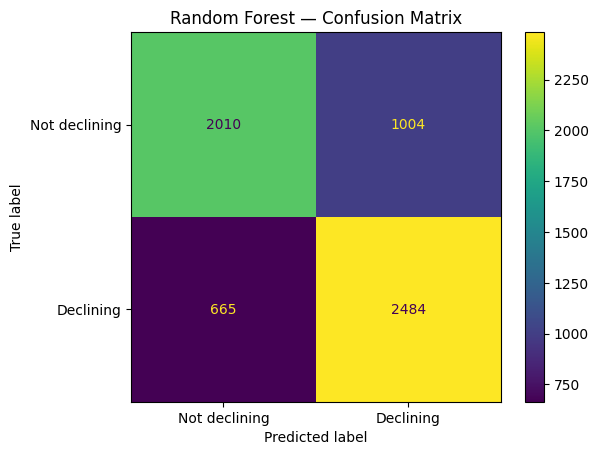


True Negatives : 2010
False Positives: 1004
False Negatives: 665
True Positives : 2484


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not declining", "Declining"]
)

disp.plot()
plt.title("Random Forest — Confusion Matrix")
plt.show()

# Individual error counts
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

###4.2 Inspect false positives and false negatives

In [ ]:
# ============================================
# Error analysis
# ============================================

error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["prediction"] = y_pred
error_analysis["decline_probability"] = y_score

# Add identifiers for interpretation
error_analysis["content_id"] = df.iloc[test_idx]["content_id"].values
error_analysis["client_id"] = df.iloc[test_idx]["client_id"].values

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["prediction"] == 1)
].sort_values(
    "decline_probability",
    ascending=False
)

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["prediction"] == 0)
].sort_values(
    "decline_probability",
    ascending=True
)

print("Number of false positives:", len(false_positives))
print("Number of false negatives:", len(false_negatives))

print("\nTop 5 false positives:")
display(
    false_positives[
        [
            "content_id",
            "client_id",
            "decline_probability",
            "days_since_last_update",
            "impressions_90d"
        ]
    ].head()
)

print("\nTop 5 false negatives:")
display(
    false_negatives[
        [
            "content_id",
            "client_id",
            "decline_probability",
            "days_since_last_update",
            "impressions_90d"
        ]
    ].head()
)

Number of false positives: 1004
Number of false negatives: 665

Top 5 false positives:


,content_id,client_id,decline_probability,days_since_last_update,impressions_90d
20736,content_41baf0722ad9,client_8527a891e2,0.852667,104,3115
2357,content_8f1409b2674e,client_8527a891e2,0.849650,104,209
12332,content_4d9f36001f06,client_8527a891e2,0.842255,104,3369
11061,content_0b47dae0c7f9,client_8527a891e2,0.835199,103,1191
29456,content_b46c62b14582,client_8527a891e2,0.823448,103,6240



Top 5 false negatives:


,content_id,client_id,decline_probability,days_since_last_update,impressions_90d
24864,content_8ab9f1033843,client_e629fa6598,0.216359,22,1265
24838,content_6dd6d7779405,client_4e07408562,0.229500,7,2609
7744,content_b26ac45aca5d,client_4e07408562,0.231238,7,2916
27575,content_284df888e0cb,client_e629fa6598,0.234348,22,287
18242,content_63a7db0259ce,client_4e07408562,0.238709,7,2921


In [ ]:
print("Top 5 false positives:")
display(
    false_positives[
        [
            "decline_probability",
            "days_since_last_update",
            "impressions_90d"
        ]
    ].head()
)

print("\nTop 5 false negatives:")
display(
    false_negatives[
        [
            "decline_probability",
            "days_since_last_update",
            "impressions_90d"
        ]
    ].head()
)

Top 5 false positives:


,decline_probability,days_since_last_update,impressions_90d
20736,0.852667,104,3115
2357,0.849650,104,209
12332,0.842255,104,3369
11061,0.835199,103,1191
29456,0.823448,103,6240



Top 5 false negatives:


,decline_probability,days_since_last_update,impressions_90d
24864,0.216359,22,1265
24838,0.229500,7,2609
7744,0.231238,7,2916
27575,0.234348,22,287
18242,0.238709,7,2921


###4.3 Feature importance

In [ ]:
from sklearn.inspection import permutation_importance

# ============================================
# Permutation importance
# ============================================

print("Calculating permutation importance...")

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

print("Top 10 features:")
display(importance_df.head(10))

Calculating permutation importance...
Top 10 features:


,feature,importance_mean,importance_std
23,impressions_prev_30d,0.219631,0.005468
20,impressions_last_30d,0.178120,0.004814
21,clicks_last_30d,0.014933,0.001427
10,impressions_90d,0.010270,0.001012
38,impression_tier,0.008939,0.000693
18,days_with_impressions,0.008438,0.001191
22,sessions_last_30d,0.005530,0.000424
33,ctr,0.003177,0.000291
34,avg_position,0.002505,0.001145
11,clicks_90d,0.001841,0.000222


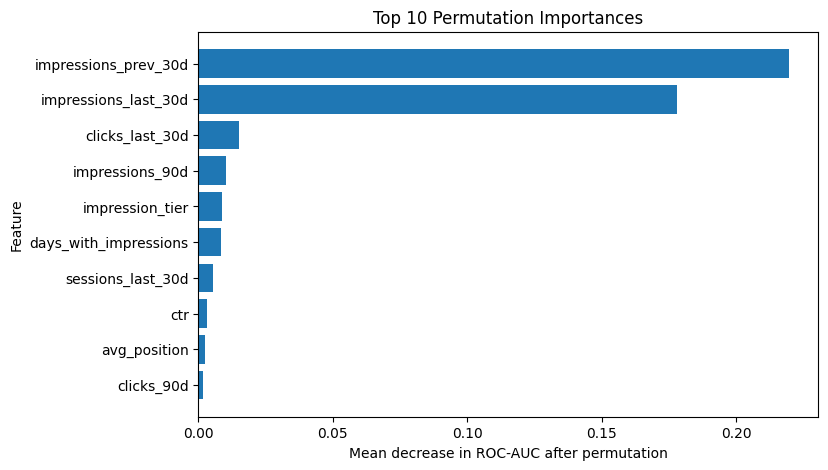

In [ ]:
top_features = importance_df.head(10).sort_values(
    "importance_mean"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Mean decrease in ROC-AUC after permutation")
plt.ylabel("Feature")
plt.title("Top 10 Permutation Importances")
plt.show()

### 4.4 Interpretation

The confusion matrix shows that the Random Forest can distinguish declining from non-declining content, although some false positives and false negatives remain.

The false-positive cases represent content that the model predicted as declining but whose observed label was not declining. These cases are important because they could lead to unnecessary content-refresh recommendations.

The false-negative cases represent declining content that the model failed to identify. These errors are particularly important from a content-refresh perspective because they may cause potentially declining content to be missed.

Permutation importance provides an additional view of the model's behavior by identifying which available features contribute most to its ROC-AUC performance. These results help explain which content, traffic, engagement, freshness, and search-related signals are most useful for distinguishing declining content.

Overall, the error analysis indicates that the model provides a useful ranking signal while still requiring human review before content-refresh decisions are made.


## 5. Self-check

* **Method choice:** Random Forest was selected because it can capture nonlinear relationships, handle mixed numerical and categorical features, and produce probability scores for ranking.
* **Leakage control:** `trend_direction`, `trend_pct`, and the derived target `is_declining_label` were excluded from the model features.
* **Split design:** A grouped train/test split was used by `client_id`, ensuring that no client appears in both training and test sets.
* **Fair comparison:** The Random Forest and Week-4 rule-based baseline were evaluated on the same held-out test set.
* **Primary ranking metric:** Precision@50 was used to evaluate the quality of the highest-priority content recommendations.
* **Observed result:** Precision@50 increased from **0.3000** for the Week-4 baseline to **0.9200** for the Random Forest, an absolute improvement of **0.6200**.
* **Generalization caution:** The result comes from one grouped holdout split, so additional validation would be useful before relying on the model in production.
* **Interpretability:** Confusion-matrix analysis, false-positive/false-negative inspection, and permutation importance were used to understand model behavior.
* **Practical limitation:** Model predictions should support, rather than automatically replace, human content-refresh decisions.
